# The Bias-Variance Tradeoff

This notebook estimates bias squared, variance and total error by Monte-Carlo simulation: many bootstrap training sets are used to fit polynomial models of increasing complexity.

## Import Required Libraries

Import numpy, matplotlib and the scikit-learn polynomial tools.

In [1]:
# Import the required libraries.
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Define the course colour palette.
colors = ["#179E86", "#2580B7", "#9EBE5B", "#C03B26", "#44546A"]

## The Data-Generating Process

A fixed sine function plus noise defines the ground truth we repeatedly sample from.

In [2]:
# Define the true function and a sampler with noise.
np.random.seed(42)

def true_fn(x):
    return np.sin(2 * np.pi * x)

def sample(n):
    x = np.sort(np.random.rand(n))
    y = true_fn(x) + np.random.normal(0, 0.25, size=n)
    return x, y

# Fixed test grid on which predictions are compared.
x_eval = np.linspace(0, 1, 100)
true_eval = true_fn(x_eval)

## Monte-Carlo Bias-Variance Decomposition

For each degree we fit many bootstrap datasets and collect the predictions on the fixed evaluation grid.

In [3]:
# Collect predictions from many bootstrap fits per degree.
degrees = range(1, 13)
n_repeats = 100
n_samples = 40

bias2, variance, total = [], [], []
preds_by_degree = {}
for d in degrees:
    preds = np.zeros((n_repeats, x_eval.size))
    for r in range(n_repeats):
        x, y = sample(n_samples)
        model = make_pipeline(PolynomialFeatures(d),
                              LinearRegression())
        model.fit(x[:, None], y)
        preds[r] = model.predict(x_eval[:, None])
    mean_pred = preds.mean(axis=0)
    bias2.append(np.mean((mean_pred - true_eval) ** 2))
    variance.append(np.mean(preds.var(axis=0)))
    total.append(np.mean((preds - true_eval) ** 2))
    preds_by_degree[d] = preds
print("Decomposition computed for degrees:", list(degrees))

Decomposition computed for degrees: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


## Plotting Bias, Variance and Total Error

As complexity grows, bias squared falls while variance rises; their sum traces the total error.

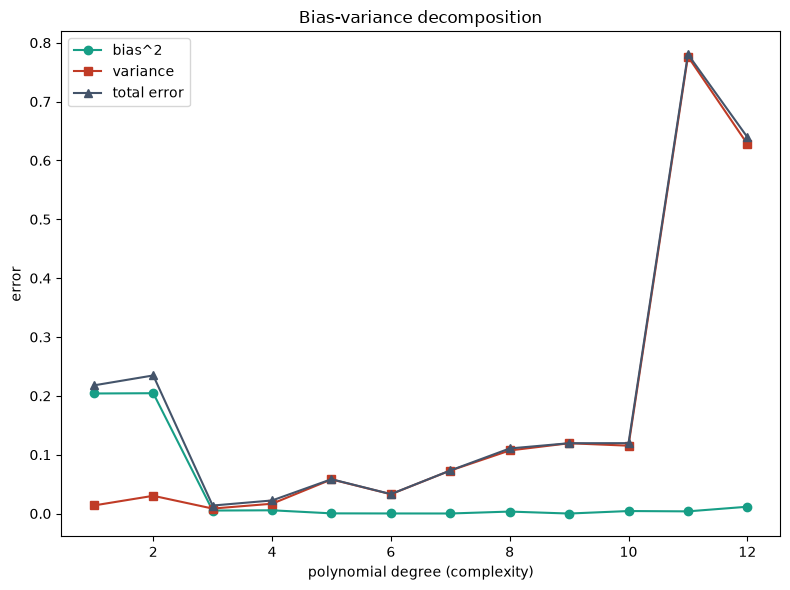

In [4]:
# Plot the estimated bias^2, variance and total error.
plt.figure(figsize=(8, 6))
plt.plot(list(degrees), bias2, marker="o", color=colors[0],
         label="bias^2")
plt.plot(list(degrees), variance, marker="s", color=colors[3],
         label="variance")
plt.plot(list(degrees), total, marker="^", color=colors[4],
         label="total error")
plt.title("Bias-variance decomposition")
plt.xlabel("polynomial degree (complexity)")
plt.ylabel("error")
plt.legend()
plt.tight_layout()
plt.show()

## Low-Complexity Fits: High Bias, Low Variance

The individual degree-1 fits are all similar to each other but far from the true curve.

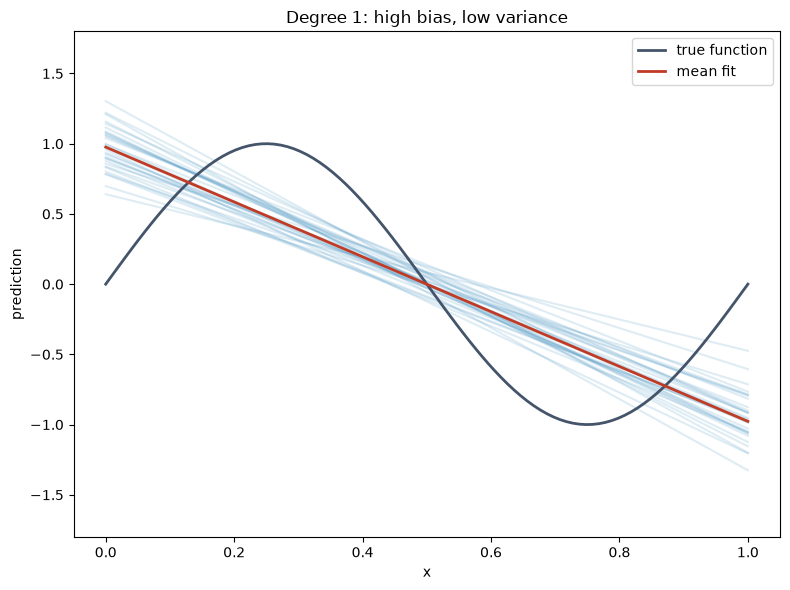

In [5]:
# Plot the individual low-complexity fits.
plt.figure(figsize=(8, 6))
for r in range(30):
    plt.plot(x_eval, preds_by_degree[1][r], color=colors[1],
             alpha=0.15)
plt.plot(x_eval, true_eval, color=colors[4], linewidth=2,
         label="true function")
plt.plot(x_eval, preds_by_degree[1].mean(axis=0),
         color=colors[3], linewidth=2, label="mean fit")
plt.ylim(-1.8, 1.8)
plt.title("Degree 1: high bias, low variance")
plt.xlabel("x")
plt.ylabel("prediction")
plt.legend()
plt.tight_layout()
plt.show()

## High-Complexity Fits: Low Bias, High Variance

The individual degree-12 fits scatter wildly around the true curve, revealing high variance.

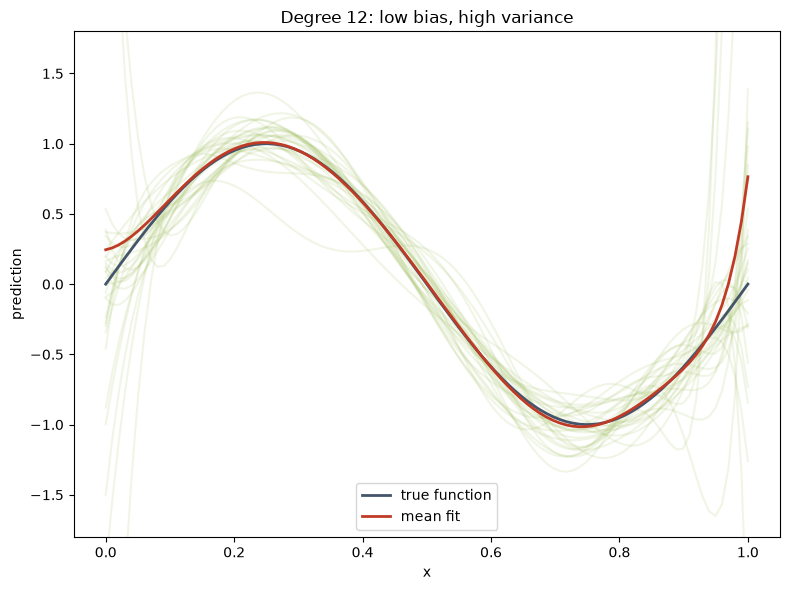

In [6]:
# Plot the individual high-complexity fits.
plt.figure(figsize=(8, 6))
for r in range(30):
    plt.plot(x_eval, preds_by_degree[12][r], color=colors[2],
             alpha=0.15)
plt.plot(x_eval, true_eval, color=colors[4], linewidth=2,
         label="true function")
plt.plot(x_eval, preds_by_degree[12].mean(axis=0),
         color=colors[3], linewidth=2, label="mean fit")
plt.ylim(-1.8, 1.8)
plt.title("Degree 12: low bias, high variance")
plt.xlabel("x")
plt.ylabel("prediction")
plt.legend()
plt.tight_layout()
plt.show()

## Summary

- **Bias**: error from overly simple models; high at low complexity.
- **Variance**: sensitivity to the training sample; high at high complexity.
- **Tradeoff**: total error is minimised where bias squared and variance balance.
- **Visual intuition**: simple fits cluster tightly but wrongly; complex fits scatter around the truth.